<a href="https://colab.research.google.com/github/Ramsi-git/Assignment-on-Statistics/blob/main/Assignment_on_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing libraries
import numpy as np
import pandas as pd

In [ ]:
#read data
df=pd.read_excel('/content/StudentsPerformance.xlsx')

In [ ]:
#get data
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group C,some high school,free/reduced,none,0,17,10
1,female,group B,high school,free/reduced,none,8,24,23
2,female,group B,some high school,free/reduced,none,18,32,28
3,female,group B,some college,standard,none,11,38,32
4,female,group C,some college,free/reduced,none,22,39,33


#1. Calculate the mean, median, and mode for the math, reading, and writing scores.

In [ ]:
for col in ['math score', 'reading score', 'writing score']:
    print(f"\n{col.upper()}")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])


MATH SCORE
Mean: 66.001
Median: 66.0
Mode: 65

READING SCORE
Mean: 69.195
Median: 70.0
Mode: 72

WRITING SCORE
Mean: 68.119
Median: 69.0
Mode: 74


#2. Determine the range, variance, and standard deviation for each score category.

In [ ]:
for col in ['math score', 'reading score', 'writing score']:
    print(f"\n{col.upper()}")
    print("Range:", df[col].max() - df[col].min())
    print("Variance:", df[col].var())
    print("Standard Deviation:", df[col].std())


MATH SCORE
Range: 100
Variance: 242.4114104104103
Standard Deviation: 15.569566802271998

READING SCORE
Range: 83
Variance: 216.27925425425406
Standard Deviation: 14.7064358107005

WRITING SCORE
Range: 90
Variance: 231.8426816816816
Standard Deviation: 15.226381109169756


#3. Identify the mean, median, and mode of math scores for students with different parental education levels.

In [ ]:
grouped = df.groupby('parental level of education')['math score']

print(grouped.agg(['mean', 'median']))

# Mode separately
mode_values = grouped.apply(lambda x: x.mode()[0])
print("\nMode:\n", mode_values)

                                  mean  median
parental level of education                   
associate's degree           67.977477    67.0
bachelor's degree            69.288136    68.0
high school                  61.821429    63.0
master's degree              70.254237    73.0
some college                 67.128319    68.0
some high school             63.134078    65.0

Mode:
 parental level of education
associate's degree    65
bachelor's degree     63
high school           57
master's degree       79
some college          69
some high school      59
Name: math score, dtype: int64


#4. Compare the mean scores of students who took the test preparation course versus those who didn’t.

In [ ]:
print(df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean())

                         math score  reading score  writing score
test preparation course                                          
completed                  69.96648      74.175978      74.684358
none                       63.78972      66.417445      64.457944


#5. Calculate the interquartile range (IQR) for each score category.

In [ ]:
for col in ['math score', 'reading score', 'writing score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"{col} IQR:", IQR)

math score IQR: 20.0
reading score IQR: 20.25
writing score IQR: 21.0


#6. Determine the standard deviation for math scores by lunch type (free/reduced vs. standard).

In [ ]:
print(df.groupby('lunch')['math score'].std())

lunch
free/reduced    15.882442
standard        13.804560
Name: math score, dtype: float64


#7. Find the correlation coefficient between math and reading scores, and then between reading and writing scores.

In [ ]:
math_reading_corr = df['math score'].corr(df['reading score'])
reading_writing_corr = df['reading score'].corr(df['writing score'])

print("Math vs Reading:", math_reading_corr)
print("Reading vs Writing:", reading_writing_corr)

Math vs Reading: 0.8149368617648359
Reading vs Writing: 0.953178417390664


#8. Interpret the strength and direction of the correlation. What might this suggest about the relationship between different scores?
#+1 → strong positive
#0 → no relationship
#-1 → strong negative

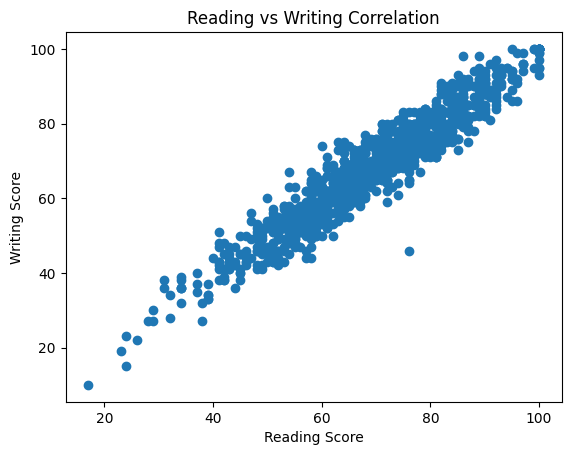

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['reading score'], df['writing score'])
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.title("Reading vs Writing Correlation")
plt.show()

The correlation values are close to +1, indicating a strong positive relationship. This means students who score high in one subject tend to score high in the other.

#9.Calculate the covariance between math and reading scores. How does it compare with the correlation? What does it suggest?

In [ ]:
cov_matrix = df[['math score', 'reading score']].cov()
print(cov_matrix)

               math score  reading score
math score     242.411410     186.598403
reading score  186.598403     216.279254


The covariance is positive, indicating that math and reading scores increase together. Compared to covariance, correlation gives a clearer measure of strength, showing a strong positive relationship.

#10. Z-Test: Assume the national average math score is 50. Use a one-sample z-test to test  if this sample's average math score is significantly different from the national average.

In [ ]:
from scipy import stats

sample_mean = df['math score'].mean()
population_mean = 50
std_dev = df['math score'].std()
n = len(df)

z = (sample_mean - population_mean) / (std_dev / np.sqrt(n))
p_value = stats.norm.sf(abs(z)) * 2  # two-tailed

print("Z-score:", z)
print("P-value:", p_value)

Z-score: 32.49904476017308
P-value: 1.0999389735449616e-231


#11. T-Test: Compare the reading scores between students with different lunch types (free/reduced vs. standard) to test if there is a significant difference.

In [ ]:
group1 = df[df['lunch'] == 'standard']['reading score']
group2 = df[df['lunch'] == 'free/reduced']['reading score']

t_stat, p_val = stats.ttest_ind(group1, group2)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 7.492798943109684
P-value: 1.4829967008771313e-13


#12. F-Test: Check if the variances of math scores differ significantlybetween students with and without test preparation.

In [ ]:
group1 = df[df['test preparation course'] == 'completed']['math score']
group2 = df[df['test preparation course'] == 'none']['math score']

f = np.var(group1, ddof=1) / np.var(group2, ddof=1)

df1 = len(group1) - 1
df2 = len(group2) - 1

# ✅ Two-tailed p-value
p_value = 2 * min(
    stats.f.cdf(f, df1, df2),
    1 - stats.f.cdf(f, df1, df2)
)

print("F-statistic:", f)
print("P-value:", p_value)

F-statistic: 0.8549283313932255
P-value: 0.09784894929843728
